In [ ]:
import pandas as pd
import numpy as np

print("\n" + "="*50)
print("FEATURE ENGINEERING: 100% DATA RETENTION (KHÔNG MẤT DỮ LIỆU)")

# Đọc dữ liệu
robusta = pd.read_csv('../data/robusta_vnd.csv', parse_dates=['Date'])
arabica = pd.read_csv('../data/arabica_vnd.csv', parse_dates=['Date'])

def create_combined_features(target_df, reference_df, target_col='Price'):
    """
    target_df: Dataframe chứa loại cà phê bạn muốn dự đoán (VD: Robusta)
    reference_df: Dataframe chứa loại cà phê tham chiếu để tính Spread (VD: Arabica)
    """
    # 1. CHUẨN BỊ VÀ GỘP DỮ LIỆU
    df = target_df.copy().sort_values('Date').reset_index(drop=True)
    
    # Lấy giá tham chiếu và lấp đầy các khoảng trống do lệch ngày nghỉ lễ giữa 2 sàn
    ref = reference_df[['Date', target_col]].copy().rename(columns={target_col: 'ref_close'})
    df = pd.merge(df, ref, on='Date', how='left')
    df['ref_close'] = df['ref_close'].ffill().bfill() # Lấp đầy giá trị trống của sàn tham chiếu
    
    p = df[target_col]

    # =========================================================
    # PHẦN 1: TỐI ƯU TARGET CHO TREE-BASED MODELS
    # =========================================================
    df['target_diff'] = p.shift(-1) - p
    df['current_price'] = p  

    # =========================================================
    # PHẦN 2: EDA INSIGHTS (ARBITRAGE)
    # =========================================================
    df['spread_A_R'] = df['ref_close'] - p
    spread_mean_30 = df['spread_A_R'].shift(1).rolling(30).mean()
    spread_std_30  = df['spread_A_R'].shift(1).rolling(30).std()
    df['spread_z_score'] = (df['spread_A_R'] - spread_mean_30) / spread_std_30

    # =========================================================
    # PHẦN 3: BỘ CHỈ BÁO KỸ THUẬT CHI TIẾT
    # =========================================================
    for lag in [1, 2, 3, 5, 7, 10, 14, 21]:
        df[f'lag_{lag}'] = p.shift(lag)

    for w in [5, 10, 20, 60]:
        df[f'roll_mean_{w}'] = p.shift(1).rolling(w).mean()
        df[f'roll_std_{w}']  = p.shift(1).rolling(w).std()
        df[f'roll_min_{w}']  = p.shift(1).rolling(w).min()
        df[f'roll_max_{w}']  = p.shift(1).rolling(w).max()

    delta = p.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df['rsi_14'] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

    ema12 = p.ewm(span=12, adjust=False).mean()
    ema26 = p.ewm(span=26, adjust=False).mean()
    df['macd']        = ema12 - ema26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_hist']   = df['macd'] - df['macd_signal']

    roll20 = p.shift(1).rolling(20)
    df['bb_mid']   = roll20.mean()
    df['bb_upper'] = df['bb_mid'] + 2 * roll20.std()
    df['bb_lower'] = df['bb_mid'] - 2 * roll20.std()
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['bb_mid']
    df['bb_pct']   = (p - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

    df['return_1d']  = p.pct_change(1)
    df['return_5d']  = p.pct_change(5)
    df['return_20d'] = p.pct_change(20)
    df['log_return'] = np.log(p / p.shift(1))

    df['momentum_5']  = p - p.shift(5)
    df['momentum_10'] = p - p.shift(10)

    if 'High' in df.columns and 'Low' in df.columns:
        df['hl_spread']     = df['High'] - df['Low']
        df['hl_spread_pct'] = df['hl_spread'] / p

    # =========================================================
    # PHẦN 4: CALENDAR & SEASONALITY
    # =========================================================
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['month']     = df['Date'].dt.month
    df['quarter']   = df['Date'].dt.quarter
    df['dayofyear'] = df['Date'].dt.dayofyear
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 5)
    df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 5)

    df['is_vietnam_harvest'] = df['month'].apply(lambda x: 1 if x in [11, 12, 1] else 0)
    df['is_brazil_frost']    = df['month'].apply(lambda x: 1 if x in [6, 7] else 0)

    # =========================================================
    # PHẦN 5: ADVANCED QUANT FEATURES
    # =========================================================
    df['roll_skew_20'] = df['return_1d'].rolling(20).skew() 
    df['roll_kurt_20'] = df['return_1d'].rolling(20).kurt() 
    df['hist_volatility_20'] = df['log_return'].rolling(20).std() * np.sqrt(252)

    conditions = [
        (p > df['roll_mean_20']) & (df['roll_mean_20'] > df['roll_mean_60']),
        (p < df['roll_mean_20']) & (df['roll_mean_20'] < df['roll_mean_60']) 
    ]
    choices = [1, -1]
    df['trend_regime'] = np.select(conditions, choices, default=0)

    if 'Vol.' in df.columns:
        df['obv'] = (np.sign(df['return_1d'].fillna(0)) * df['Vol.']).cumsum()
        
        df['up_volume'] = np.where(df['return_1d'] > 0, df['Vol.'], 0)
        df['down_volume'] = np.where(df['return_1d'] < 0, df['Vol.'], 0)
        roll_vol = df['Vol.'].rolling(5).sum() + 1e-9
        df['vol_imbalance_5d'] = (df['up_volume'].rolling(5).sum() - df['down_volume'].rolling(5).sum()) / roll_vol
        df.drop(columns=['up_volume', 'down_volume'], inplace=True)

    # =========================================================
    # PHẦN 6: LẤP ĐẦY DỮ LIỆU ĐỂ GIỮ NGUYÊN 100% SỐ DÒNG
    # =========================================================
    # Thay vì dùng df.dropna(), ta đắp ngược dữ liệu từ các ngày sau lên ngày trước
    # và thay thế các ô vẫn còn trống bằng 0.
    df = df.bfill().ffill().fillna(0)

    exclude_cols = ['Date', 'coffee_type', 'target_diff', 'current_price', 'ref_close']
    n_feat = len([c for c in df.columns if c not in exclude_cols])
    
    print(f"Features: {n_feat} cột | Số dòng bảo toàn: {len(df)}")
    return df

# Chạy tạo features 
robusta_fe = create_combined_features(robusta, arabica, target_col='Price')
arabica_fe = create_combined_features(arabica, robusta, target_col='Price')

robusta_fe.to_csv('data/robusta_features_v4.csv', index=False)
arabica_fe.to_csv('data/arabica_features_v4.csv', index=False)
print("\n✅ Đã lưu phiên bản bảo toàn 100% dữ liệu: data/robusta_features_v4.csv và data/arabica_features_v4.csv")


FEATURE ENGINEERING: 100% DATA RETENTION (KHÔNG MẤT DỮ LIỆU)
Features: 65 cột | Số dòng bảo toàn: 766
Features: 65 cột | Số dòng bảo toàn: 761

✅ Đã lưu phiên bản bảo toàn 100% dữ liệu: data/robusta_features_v4.csv và data/arabica_features_v4.csv



PHASE 3: TIME-SERIES MODELING (RANDOM FOREST vs XGBOOST)
Kích thước tập dữ liệu (Đã bỏ 60 dòng đầu): 706 dòng
  + Train Set : (494, 65)
  + Val Set   : (106, 65)
  + Test Set  : (106, 65)

Đang huấn luyện Random Forest bằng GridSearchCV...
Best RF Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

--- ĐÁNH GIÁ MÔ HÌNH: RANDOM FOREST (VALIDATION SET) ---
MAE (Sai số tuyệt đối): 2,778 VND/kg
RMSE                  : 3,436 VND/kg
Directional Accuracy  : 44.34%

Đang huấn luyện XGBoost bằng GridSearchCV...
Best XGB Params: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

--- ĐÁNH GIÁ MÔ HÌNH: XGBOOST (VALIDATION SET) ---
MAE (Sai số tuyệt đối): 2,547 VND/kg
RMSE                  : 3,163 VND/kg
Directional Accuracy  : 45.28%

 KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST (DỮ LIỆU CHƯA TỪNG THẤY)
--- ĐÁNH GIÁ MÔ HÌNH: RANDOM FOREST (TEST SET) ---
MAE (Sai số tuyệt đối): 1,735 VND/kg
RMSE                  :

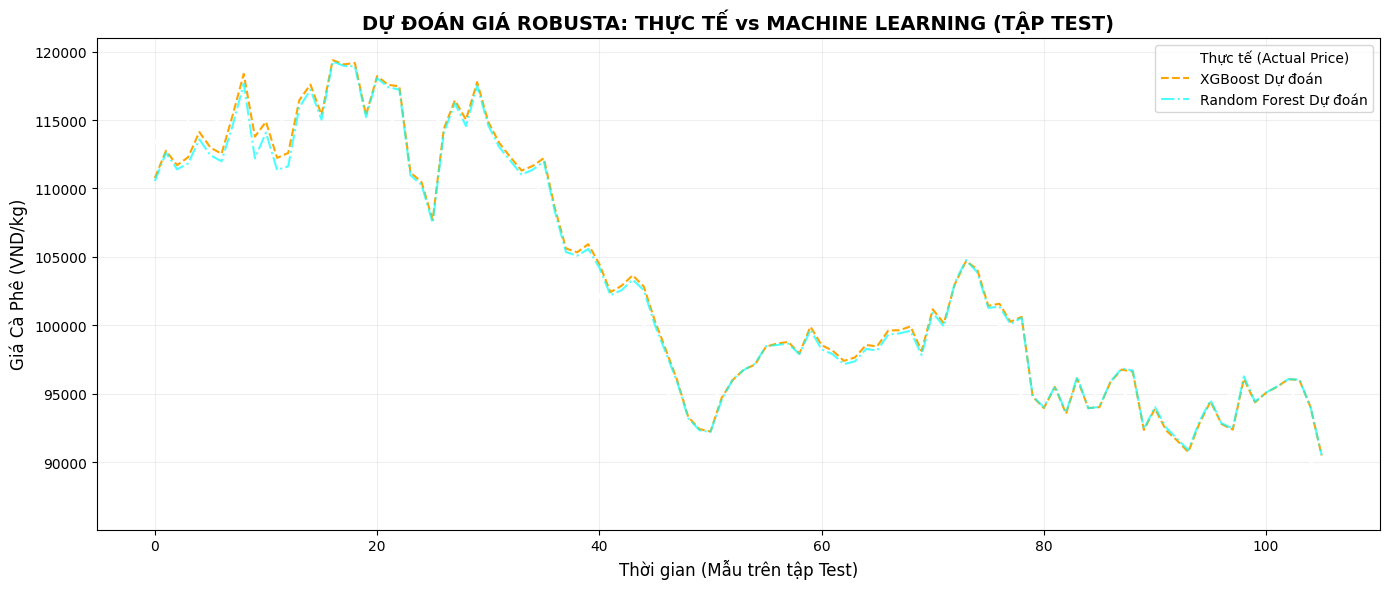

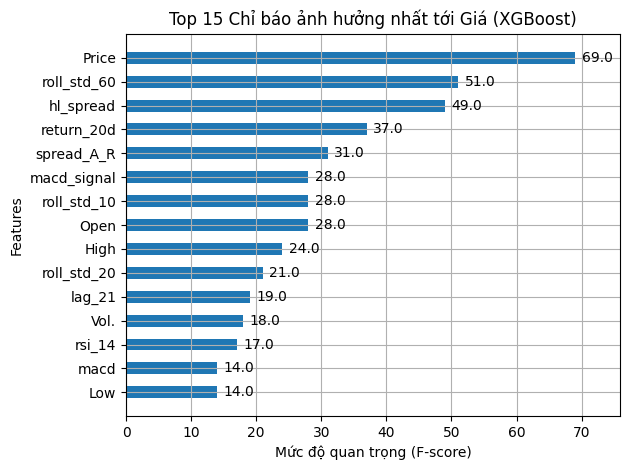

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("\n" + "="*50)
print("PHASE 3: TIME-SERIES MODELING (RANDOM FOREST vs XGBOOST)")
print("="*50)

# Giả định 'robusta_fe' là dataframe từ bước Feature Engineering trước đó
df_model = robusta_fe.copy()

# =========================================================
# BƯỚC 1: XỬ LÝ DỮ LIỆU & CHIA TẬP TRAIN - VAL - TEST
# =========================================================
# 1. Cắt bỏ 60 dòng đầu tiên (chứa dữ liệu ảo do backward fill)
df_model = df_model.iloc[60:].reset_index(drop=True)

# 2. Tách Target và Features
# Lưu ý: Cột 'current_price' PHẢI được tách riêng, không cho mô hình học
prices = df_model['current_price']
y = df_model['target_diff']

# Bỏ các cột không phải số (Date, coffee_type) và các cột mục tiêu/tham chiếu
cols_to_drop = ['Date', 'coffee_type', 'target_diff', 'current_price', 'ref_close']
X = df_model.drop(columns=[col for col in cols_to_drop if col in df_model.columns])

# 3. Chia tập theo thời gian: Train (70%) - Validation (15%) - Test (15%)
n = len(df_model)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val     = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test   = X.iloc[val_end:], y.iloc[val_end:]

# Giữ lại giá tuyệt đối của tập Test để lát sau đánh giá
prices_test = prices.iloc[val_end:]

print(f"Kích thước tập dữ liệu (Đã bỏ 60 dòng đầu): {len(df_model)} dòng")
print(f"  + Train Set : {X_train.shape}")
print(f"  + Val Set   : {X_val.shape}")
print(f"  + Test Set  : {X_test.shape}\n")

# Khởi tạo TimeSeriesSplit cho GridSearch (Tránh rò rỉ tương lai trong Cross-Validation)
tscv = TimeSeriesSplit(n_splits=3)

# =========================================================
# HÀM ĐÁNH GIÁ (BUSINESS METRICS)
# =========================================================
def evaluate_model(model, name, X_eval, y_eval, base_prices):
    # Dự đoán mức chênh lệch (Difference)
    pred_diff = model.predict(X_eval)
    
    # Cộng ngược mức chênh lệch vào giá hôm nay để ra giá ngày mai
    pred_abs_price = base_prices.values + pred_diff
    actual_abs_price = base_prices.values + y_eval.values
    
    # Tính Metrics
    mae = mean_absolute_error(actual_abs_price, pred_abs_price)
    rmse = np.sqrt(mean_squared_error(actual_abs_price, pred_abs_price))
    
    # Directional Accuracy (Tỷ lệ đoán đúng hướng Tăng/Giảm)
    # Cùng dấu = Đoán đúng hướng (>0)
    correct_dir = np.sum(np.sign(pred_diff) == np.sign(y_eval.values))
    dir_acc = (correct_dir / len(y_eval)) * 100
    
    print(f"--- ĐÁNH GIÁ MÔ HÌNH: {name} ---")
    print(f"MAE (Sai số tuyệt đối): {mae:,.0f} VND/kg")
    print(f"RMSE                  : {rmse:,.0f} VND/kg")
    print(f"Directional Accuracy  : {dir_acc:.2f}%\n")
    
    return pred_abs_price, actual_abs_price

# =========================================================
# BƯỚC 2: TRAIN & TUNE RANDOM FOREST
# =========================================================
print("Đang huấn luyện Random Forest bằng GridSearchCV...")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf_model = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(rf_model, rf_params, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print(f"Best RF Params: {rf_grid.best_params_}\n")

# Đánh giá RF trên tập Validation
evaluate_model(best_rf, "RANDOM FOREST (VALIDATION SET)", X_val, y_val, prices.iloc[train_end:val_end])


# =========================================================
# BƯỚC 3: TRAIN & TUNE XGBOOST
# =========================================================
print("Đang huấn luyện XGBoost bằng GridSearchCV...")
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, tree_method='hist')
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)

# XGBoost có thể tận dụng tập Validation (eval_set) để Early Stopping, 
# nhưng ở đây ta dùng GridSearch chuẩn mực trước.
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print(f"Best XGB Params: {xgb_grid.best_params_}\n")

# Đánh giá XGBoost trên tập Validation
evaluate_model(best_xgb, "XGBOOST (VALIDATION SET)", X_val, y_val, prices.iloc[train_end:val_end])


# =========================================================
# BƯỚC 4: CHỐT HẠ KẾT QUẢ TRÊN TẬP TEST (UNSEEN DATA)
# =========================================================
print("="*50)
print(" KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST (DỮ LIỆU CHƯA TỪNG THẤY)")
print("="*50)

# Giả sử qua tập Val, bạn thấy XGBoost tốt hơn (thường là vậy), ta mang XGBoost đi Test
# Hoặc in cả 2 ra để so sánh
pred_rf_test, actual_test = evaluate_model(best_rf, "RANDOM FOREST (TEST SET)", X_test, y_test, prices_test)
pred_xgb_test, _ = evaluate_model(best_xgb, "XGBOOST (TEST SET)", X_test, y_test, prices_test)

# =========================================================
# BƯỚC 5: TRỰC QUAN HÓA KẾT QUẢ XGBOOST TRÊN TẬP TEST
# =========================================================
plt.figure(figsize=(14, 6))
# Lấy trục X là index hoặc Date (nếu còn giữ index)
plt.plot(actual_test, label='Thực tế (Actual Price)', color='white', linewidth=2)
plt.plot(pred_xgb_test, label='XGBoost Dự đoán', color='orange', linestyle='--', linewidth=1.5)
plt.plot(pred_rf_test, label='Random Forest Dự đoán', color='cyan', linestyle='-.', linewidth=1.5, alpha=0.7)

plt.title('DỰ ĐOÁN GIÁ ROBUSTA: THỰC TẾ vs MACHINE LEARNING (TẬP TEST)', fontsize=14, fontweight='bold')
plt.ylabel('Giá Cà Phê (VND/kg)', fontsize=12)
plt.xlabel('Thời gian (Mẫu trên tập Test)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
# plt.style.use('dark_background') # Bỏ comment nếu muốn hình nền đen ngầu như hacker
plt.tight_layout()
plt.show()

# (Tùy chọn) Vẽ Feature Importance cho XGBoost
xgb.plot_importance(best_xgb, max_num_features=15, height=0.5, 
                    title="Top 15 Chỉ báo ảnh hưởng nhất tới Giá (XGBoost)", 
                    xlabel="Mức độ quan trọng (F-score)", ylabel="Features")
plt.tight_layout()
plt.show()


📊 ĐÁNH GIÁ MÔ HÌNH: XGBOOST
✅ MAE  (Mean Absolute Error)     : 1,708 VND/kg
✅ MSE  (Mean Squared Error)      : 4,959,215
✅ RMSE (Root Mean Squared Error) : 2,227 VND/kg
🎯 Directional Accuracy           : 43.40%


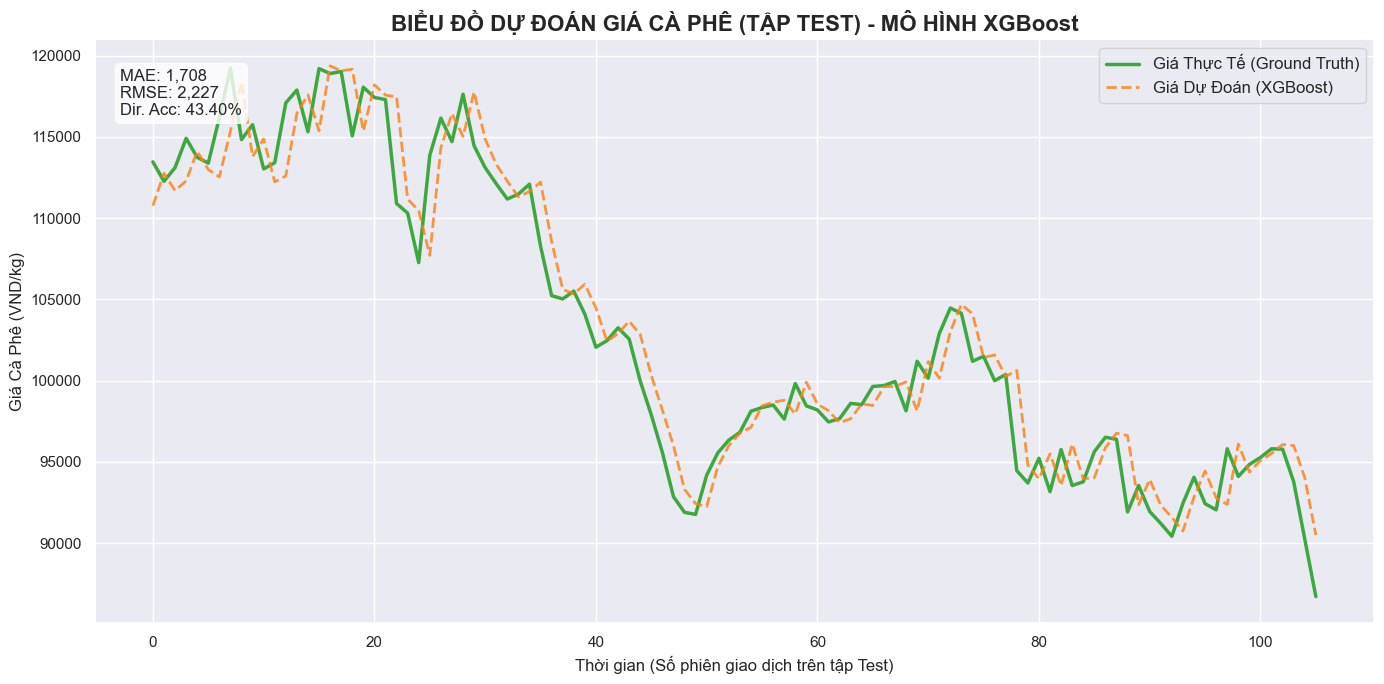


📊 ĐÁNH GIÁ MÔ HÌNH: RANDOM FOREST
✅ MAE  (Mean Absolute Error)     : 1,735 VND/kg
✅ MSE  (Mean Squared Error)      : 5,159,606
✅ RMSE (Root Mean Squared Error) : 2,271 VND/kg
🎯 Directional Accuracy           : 50.00%


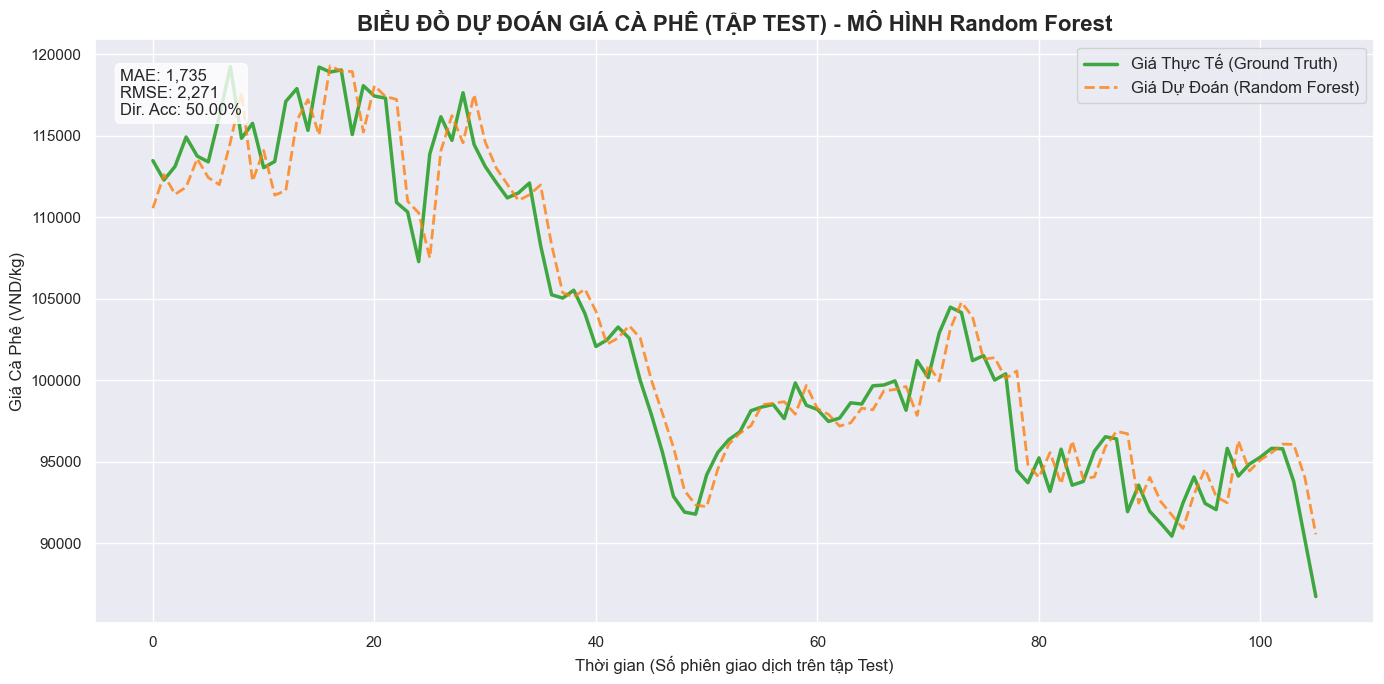

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Đặt style cho biểu đồ đẹp hơn (Tùy chọn)
sns.set_theme(style="darkgrid")

def evaluate_and_plot(model, X_test, y_test, base_prices, model_name="XGBoost"):
    """
    Hàm này nhận vào mô hình, dữ liệu test, và giá gốc để:
    1. Tính toán MAE, MSE, RMSE trên giá tuyệt đối (VND/kg)
    2. Vẽ biểu đồ so sánh Thực tế vs Dự đoán
    """
    print(f"\n" + "="*50)
    print(f"📊 ĐÁNH GIÁ MÔ HÌNH: {model_name.upper()}")
    print("="*50)

    # 1. DỰ ĐOÁN VÀ KHÔI PHỤC GIÁ TUYỆT ĐỐI
    pred_diff = model.predict(X_test)
    
    # Giá dự đoán = Giá hiện tại + Mức chênh lệch dự đoán
    pred_price = base_prices.values + pred_diff
    # Giá thực tế = Giá hiện tại + Mức chênh lệch thực tế
    actual_price = base_prices.values + y_test.values

    # 2. TÍNH TOÁN CÁC CHỈ SỐ METRICS
    mae = mean_absolute_error(actual_price, pred_price)
    mse = mean_squared_error(actual_price, pred_price)
    rmse = np.sqrt(mse)
    
    # Directional Accuracy (Đoán đúng hướng Tăng/Giảm)
    correct_dir = np.sum(np.sign(pred_diff) == np.sign(y_test.values))
    dir_acc = (correct_dir / len(y_test)) * 100

    print(f"✅ MAE  (Mean Absolute Error)     : {mae:,.0f} VND/kg")
    print(f"✅ MSE  (Mean Squared Error)      : {mse:,.0f}")
    print(f"✅ RMSE (Root Mean Squared Error) : {rmse:,.0f} VND/kg")
    print(f"🎯 Directional Accuracy           : {dir_acc:.2f}%")

    # 3. VẼ BIỂU ĐỒ SO SÁNH
    plt.figure(figsize=(14, 7))
    
    # Trục X là thời gian (Dùng index của tập test để minh họa)
    time_axis = range(len(actual_price))
    
    plt.plot(time_axis, actual_price, label='Giá Thực Tế (Ground Truth)', 
             color='#2ca02c', linewidth=2.5, alpha=0.9) # Màu xanh lá
    
    plt.plot(time_axis, pred_price, label=f'Giá Dự Đoán ({model_name})', 
             color='#ff7f0e', linestyle='--', linewidth=2, alpha=0.8) # Màu cam
    
    plt.title(f'BIỂU ĐỒ DỰ ĐOÁN GIÁ CÀ PHÊ (TẬP TEST) - MÔ HÌNH {model_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Thời gian (Số phiên giao dịch trên tập Test)', fontsize=12)
    plt.ylabel('Giá Cà Phê (VND/kg)', fontsize=12)
    
    # Thêm text box chứa Metrics vào góc biểu đồ
    metrics_text = f"MAE: {mae:,.0f}\nRMSE: {rmse:,.0f}\nDir. Acc: {dir_acc:.2f}%"
    plt.text(0.02, 0.95, metrics_text, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()
    plt.show()

# ==========================================
# CÁCH SỬ DỤNG (Giả sử bạn đã chạy xong best_xgb ở bước trước):
# Chú ý: Cần truyền vào base_prices là giá của tập Test để cộng ngược lại
# ==========================================
evaluate_and_plot(best_xgb, X_test, y_test, prices_test, model_name="XGBoost")
evaluate_and_plot(best_rf, X_test, y_test, prices_test, model_name="Random Forest")


PHASE 4: ADVANCED MODELING (LIGHTGBM & LSTM)

[1/2] Đang huấn luyện LightGBM bằng GridSearchCV...
✅ Best LightGBM Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 20}

[2/2] Đang chuẩn bị dữ liệu và huấn luyện LSTM...


/Users/minh/Documents/Ky_2_nam_3/CS313/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ Đã huấn luyện xong LSTM. Dừng lại ở Epoch 17.

🏆 KẾT QUẢ CẠNH TRANH TRÊN TẬP TEST 🏆
[LIGHTGBM] MAE: 1,799 | RMSE: 2,322 | Dir. Acc: 41.51%
[LSTM]     MAE: 1,658 | RMSE: 2,174 | Dir. Acc: 47.17%


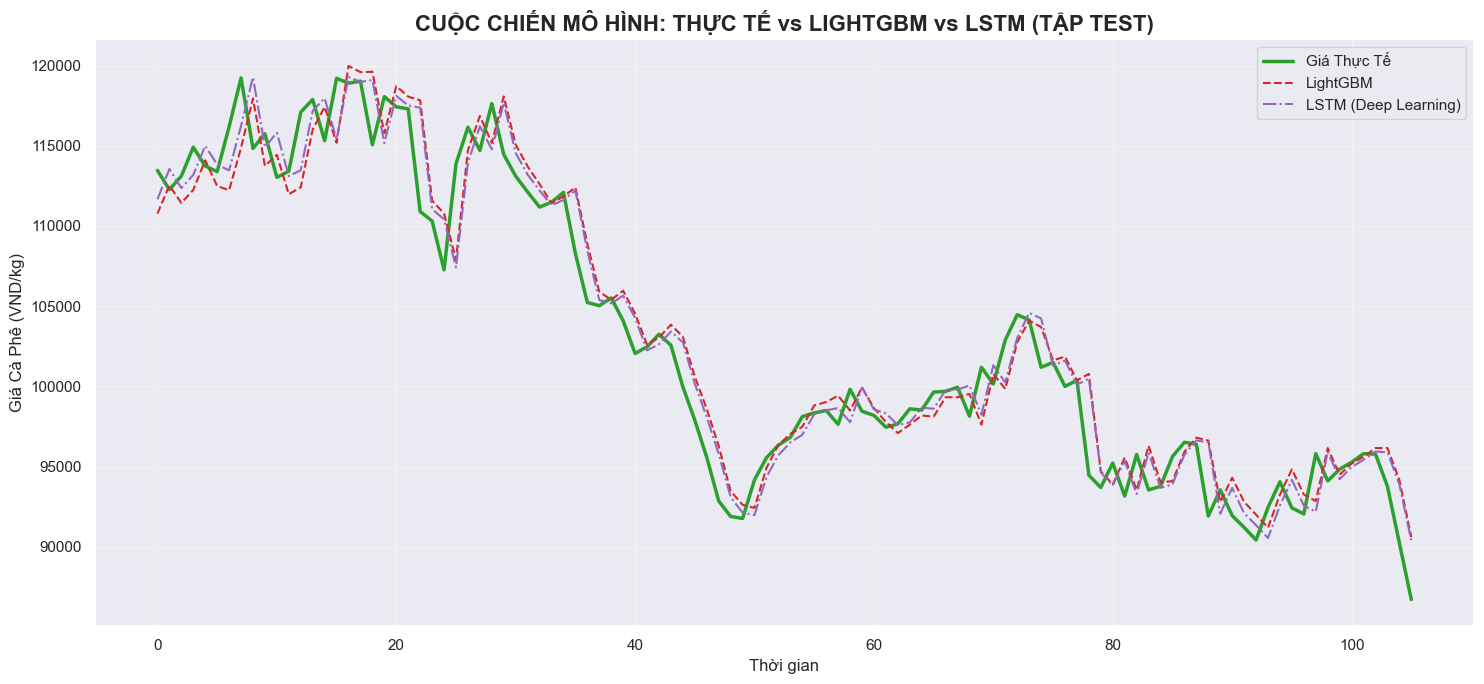

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("\n" + "="*50)
print("PHASE 4: ADVANCED MODELING (LIGHTGBM & LSTM)")
print("="*50)

# (Giả định bạn đã có X_train, y_train, X_val, y_val, X_test, y_test, prices_test từ code trước)
tscv = TimeSeriesSplit(n_splits=3)

# =========================================================
# 1. LIGHTGBM (CỖ MÁY SIÊU TỐC)
# =========================================================
print("\n[1/2] Đang huấn luyện LightGBM bằng GridSearchCV...")
lgb_params = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'max_depth': [-1, 5, 7] # -1 nghĩa là không giới hạn
}

lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
lgb_grid = GridSearchCV(lgb_model, lgb_params, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)

lgb_grid.fit(X_train, y_train)
best_lgb = lgb_grid.best_estimator_
print(f"✅ Best LightGBM Params: {lgb_grid.best_params_}")

# Dự đoán và tính giá tuyệt đối
pred_diff_lgb = best_lgb.predict(X_test)
pred_price_lgb = prices_test.values + pred_diff_lgb
actual_price = prices_test.values + y_test.values


# =========================================================
# 2. LSTM DEEP LEARNING (MẠNG NƠ-RON HỒI QUY)
# =========================================================
print("\n[2/2] Đang chuẩn bị dữ liệu và huấn luyện LSTM...")

# BƯỚC A: CHUẨN HÓA DỮ LIỆU (SCALING - Bắt buộc cho Deep Learning)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Mẹo Tài chính: Vì target là mức chênh lệch (tiền nghìn VND), ta nên scale target 
# để mạng Neural học hội tụ nhanh hơn.
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))

# BƯỚC B: RESHAPE THÀNH 3D CHO LSTM (Samples, TimeSteps, Features)
# Vì bộ Features của bạn đã chứa sẵn độ trễ (Lags) và Moving Averages,
# ta coi mỗi dòng như 1 timestep chứa đựng toàn bộ lịch sử.
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_val_lstm = X_val_scaled.reshape(X_val_scaled.shape[0], 1, X_val_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# BƯỚC C: XÂY DỰNG KIẾN TRÚC MẠNG LSTM
lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) # Lớp đầu ra dự đoán target_diff
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# BƯỚC D: HUẤN LUYỆN VỚI EARLY STOPPING (Dừng sớm nếu thấy dấu hiệu Overfitting)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train_scaled,
    validation_data=(X_val_lstm, y_val_scaled),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0 # Đổi thành 1 nếu bạn muốn xem epoch chạy
)
print(f"✅ Đã huấn luyện xong LSTM. Dừng lại ở Epoch {len(history.history['loss'])}.")

# BƯỚC E: DỰ ĐOÁN VÀ ĐẢO NGƯỢC SCALING
pred_diff_scaled_lstm = lstm_model.predict(X_test_lstm, verbose=0)
pred_diff_lstm = scaler_y.inverse_transform(pred_diff_scaled_lstm).flatten()
pred_price_lstm = prices_test.values + pred_diff_lstm


# =========================================================
# 3. ĐÁNH GIÁ CHUNG VÀ VẼ BIỂU ĐỒ (TẬP TEST)
# =========================================================
def get_metrics(actual, pred, diff_actual, diff_pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    dir_acc = (np.sum(np.sign(diff_pred) == np.sign(diff_actual)) / len(actual)) * 100
    return mae, rmse, dir_acc

mae_lgb, rmse_lgb, dir_lgb = get_metrics(actual_price, pred_price_lgb, y_test.values, pred_diff_lgb)
mae_lstm, rmse_lstm, dir_lstm = get_metrics(actual_price, pred_price_lstm, y_test.values, pred_diff_lstm)

print("\n" + "="*50)
print("🏆 KẾT QUẢ CẠNH TRANH TRÊN TẬP TEST 🏆")
print("="*50)
print(f"[LIGHTGBM] MAE: {mae_lgb:,.0f} | RMSE: {rmse_lgb:,.0f} | Dir. Acc: {dir_lgb:.2f}%")
print(f"[LSTM]     MAE: {mae_lstm:,.0f} | RMSE: {rmse_lstm:,.0f} | Dir. Acc: {dir_lstm:.2f}%")

# Vẽ biểu đồ so sánh
plt.figure(figsize=(15, 7))
time_axis = range(len(actual_price))

plt.plot(time_axis, actual_price, label='Giá Thực Tế', color='#2ca02c', linewidth=2.5)
plt.plot(time_axis, pred_price_lgb, label='LightGBM', color='#d62728', linestyle='--', linewidth=1.5)
plt.plot(time_axis, pred_price_lstm, label='LSTM (Deep Learning)', color='#9467bd', linestyle='-.', linewidth=1.5)

plt.title('CUỘC CHIẾN MÔ HÌNH: THỰC TẾ vs LIGHTGBM vs LSTM (TẬP TEST)', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá Cà Phê (VND/kg)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


PHASE 5: LINEAR REGRESSION MASTERY (RIDGE & LASSO)

[1/2] Đang huấn luyện Ridge Regression...
✅ Best Ridge Alpha: 1000.0

[2/2] Đang huấn luyện Lasso Regression...


/Users/minh/Documents/Ky_2_nam_3/CS313/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.525e+07, tolerance: 1.440e+04
  model = cd_fast.enet_coordinate_descent(
/Users/minh/Documents/Ky_2_nam_3/CS313/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.893e+08, tolerance: 6.351e+04
  model = cd_fast.enet_coordinate_descent(
/Users/minh/Documents/Ky_2_nam_3/CS313/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

✅ Best Lasso Alpha: 10.0

🏆 KẾT QUẢ RIDGE vs LASSO TRÊN TẬP TEST 🏆
[RIDGE] MAE: 1,681 | RMSE: 2,219 | Dir. Acc: 46.23%
[LASSO] MAE: 2,338 | RMSE: 3,105 | Dir. Acc: 51.89%

🔍 LASSO FEATURE SELECTION INSIGHTS 🔍
Tổng số tính năng ban đầu: 65
Số tính năng được giữ lại : 26
Số tính năng bị LOẠI BỎ   : 39

Danh sách một vài tính năng bị 'khai tử' (Vô dụng với mô hình tuyến tính):
<StringArray>
[   'Price',     'Open',     'High',      'Low',     'Vol.', 'Change %',
    'lag_1',    'lag_2',    'lag_3',    'lag_5']
Length: 10, dtype: str


/Users/minh/Documents/Ky_2_nam_3/CS313/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.265e+06, tolerance: 6.351e+04
  model = cd_fast.enet_coordinate_descent(
/Users/minh/Documents/Ky_2_nam_3/CS313/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.012e+07, tolerance: 1.545e+05
  model = cd_fast.enet_coordinate_descent(


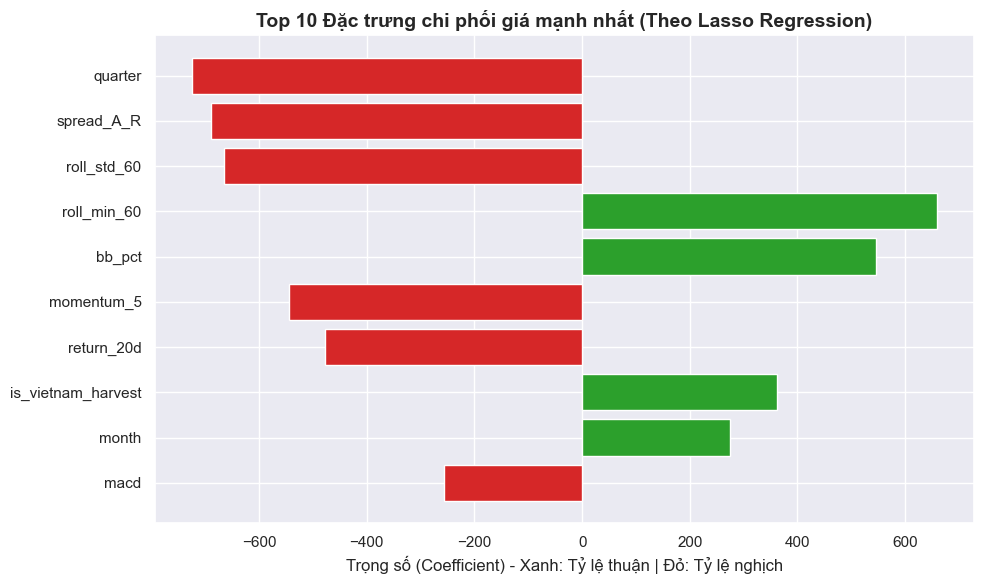

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("\n" + "="*50)
print("PHASE 5: LINEAR REGRESSION MASTERY (RIDGE & LASSO)")
print("="*50)

# 1. SCALING DỮ LIỆU (BẮT BUỘC CHO RIDGE/LASSO)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

tscv = TimeSeriesSplit(n_splits=3)

# =========================================================
# MÔ HÌNH 1: RIDGE REGRESSION (Chống Đa cộng tuyến)
# =========================================================
print("\n[1/2] Đang huấn luyện Ridge Regression...")
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

ridge_model = Ridge(random_state=42)
ridge_grid = GridSearchCV(ridge_model, ridge_params, cv=tscv, scoring='neg_mean_absolute_error')
ridge_grid.fit(X_train_scaled, y_train)

best_ridge = ridge_grid.best_estimator_
print(f"✅ Best Ridge Alpha: {best_ridge.alpha}")

# =========================================================
# MÔ HÌNH 2: LASSO REGRESSION (Tuyển chọn Đặc trưng)
# =========================================================
print("\n[2/2] Đang huấn luyện Lasso Regression...")
# Lasso cần alpha nhỏ hơn vì nó phạt rất nặng
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]} 

lasso_model = Lasso(random_state=42, max_iter=10000) # Tăng max_iter để đảm bảo hội tụ
lasso_grid = GridSearchCV(lasso_model, lasso_params, cv=tscv, scoring='neg_mean_absolute_error')
lasso_grid.fit(X_train_scaled, y_train)

best_lasso = lasso_grid.best_estimator_
print(f"✅ Best Lasso Alpha: {best_lasso.alpha}")


# =========================================================
# 3. ĐÁNH GIÁ TRÊN TẬP TEST
# =========================================================
def get_metrics(actual, pred, diff_actual, diff_pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    dir_acc = (np.sum(np.sign(diff_pred) == np.sign(diff_actual)) / len(actual)) * 100
    return mae, rmse, dir_acc

actual_price = prices_test.values + y_test.values

# Dự đoán bằng Ridge
pred_diff_ridge = best_ridge.predict(X_test_scaled)
pred_price_ridge = prices_test.values + pred_diff_ridge
mae_ridge, rmse_ridge, dir_ridge = get_metrics(actual_price, pred_price_ridge, y_test.values, pred_diff_ridge)

# Dự đoán bằng Lasso
pred_diff_lasso = best_lasso.predict(X_test_scaled)
pred_price_lasso = prices_test.values + pred_diff_lasso
mae_lasso, rmse_lasso, dir_lasso = get_metrics(actual_price, pred_price_lasso, y_test.values, pred_diff_lasso)

print("\n" + "="*50)
print("🏆 KẾT QUẢ RIDGE vs LASSO TRÊN TẬP TEST 🏆")
print("="*50)
print(f"[RIDGE] MAE: {mae_ridge:,.0f} | RMSE: {rmse_ridge:,.0f} | Dir. Acc: {dir_ridge:.2f}%")
print(f"[LASSO] MAE: {mae_lasso:,.0f} | RMSE: {rmse_lasso:,.0f} | Dir. Acc: {dir_lasso:.2f}%")

# =========================================================
# 4. TRÍCH XUẤT INSIGHT TỪ LASSO (RẤT HAY CHO BÁO CÁO)
# =========================================================
# Lấy danh sách các tính năng và trọng số của Lasso
lasso_coefs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lasso.coef_
})

# Đếm số tính năng bị Lasso loại bỏ (Coefficient == 0)
features_kept = lasso_coefs[lasso_coefs['Coefficient'] != 0]
features_dropped = lasso_coefs[lasso_coefs['Coefficient'] == 0]

print("\n" + "="*50)
print("🔍 LASSO FEATURE SELECTION INSIGHTS 🔍")
print("="*50)
print(f"Tổng số tính năng ban đầu: {len(X.columns)}")
print(f"Số tính năng được giữ lại : {len(features_kept)}")
print(f"Số tính năng bị LOẠI BỎ   : {len(features_dropped)}")

if len(features_dropped) > 0:
    print(f"\nDanh sách một vài tính năng bị 'khai tử' (Vô dụng với mô hình tuyến tính):")
    print(features_dropped['Feature'].values[:10]) # In ra 10 cái tên đầu tiên

# Vẽ biểu đồ Top 10 Tính năng quan trọng nhất theo thuật toán Linear
top_features = features_kept.reindex(features_kept.Coefficient.abs().sort_values(ascending=False).index).head(10)

plt.figure(figsize=(10, 6))
# Nếu coefficient dương thì màu xanh (kéo giá lên), âm thì màu đỏ (kéo giá xuống)
colors = ['#2ca02c' if c > 0 else '#d62728' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'][::-1], top_features['Coefficient'][::-1], color=colors[::-1])
plt.title('Top 10 Đặc trưng chi phối giá mạnh nhất (Theo Lasso Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Trọng số (Coefficient) - Xanh: Tỷ lệ thuận | Đỏ: Tỷ lệ nghịch', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
X_train

,Price,Open,High,Low,Vol.,Change %,spread_A_R,spread_z_score,lag_1,lag_2,...,dow_sin,dow_cos,is_vietnam_harvest,is_brazil_frost,roll_skew_20,roll_kurt_20,hist_volatility_20,trend_regime,obv,vol_imbalance_5d
0,64008.0,63881.0,64185.8,63550.8,9160.0,0.00,36031.262202,-1.810411,64008.0,64211.2,...,0.587785,-0.809017,0,0,-0.662115,-0.123141,0.280774,1,123930.0,-0.006784
1,65201.8,64135.0,65532.0,64135.0,8430.0,1.87,37301.345514,-1.391984,64008.0,64008.0,...,-0.587785,-0.809017,0,1,-0.696098,-0.229503,0.286389,1,132360.0,0.090408
2,64566.8,65303.4,65633.6,64389.0,9090.0,-0.97,36396.418444,-1.517713,65201.8,64008.0,...,-0.951057,0.309017,0,1,-0.602240,-0.452377,0.289775,1,123270.0,-0.053975
3,65379.6,64592.2,65455.8,64008.0,8050.0,1.26,37151.544188,-1.317047,64566.8,65201.8,...,0.000000,1.000000,0,1,-0.744529,-0.318796,0.290542,1,131320.0,0.030333
4,65608.2,65532.0,66090.8,64998.6,13980.0,0.35,36642.957448,-1.418497,65379.6,64566.8,...,0.951057,0.309017,0,1,-0.736267,-0.183066,0.279874,1,145300.0,0.438719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,133502.4,134188.2,136118.6,132257.8,7990.0,-0.66,84803.261178,0.966384,134391.4,130200.4,...,0.951057,0.309017,0,0,-0.822533,0.172265,0.437199,0,516550.0,-0.277669
490,133070.6,133299.2,134924.8,132715.0,4820.0,-0.32,82015.213668,0.506572,133502.4,134391.4,...,0.587785,-0.809017,0,0,-0.987694,1.203543,0.401728,0,511730.0,-0.218077
491,133731.0,133146.8,134645.4,132511.8,4130.0,0.50,83174.727478,0.666589,133070.6,133502.4,...,-0.587785,-0.809017,0,0,-0.588767,0.801256,0.317943,0,515860.0,-0.247980
492,132740.4,133985.0,134772.4,131775.2,4740.0,-0.74,84389.316870,0.833406,133731.0,133070.6,...,-0.951057,0.309017,0,0,-0.461900,0.559116,0.320747,0,511120.0,-0.183811
